# 05 — Model What-if: Intervention Simulation

Train a separate LightGBM model using `first_meaningful_intervention` (the first non-administrative service a client received in their full history). This model powers the **Simulate Intervention** feature in the Streamlit app.

**Key difference vs Model 1:**
- Model 1 uses `first_intervention_type` from the **first snapshot** (available at intake)
- Model What-if uses `first_meaningful_intervention` from **full history** (intentional leakage — declared)

**Purpose:** Allow caseworkers to select a planned intervention and see the estimated risk change.

> ⚠️ Disclaimer: This model uses historical data — results reflect **association, not causation**.

In [10]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import lightgbm as lgb
import optuna
import shap
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, f1_score, recall_score, classification_report
import joblib
from datetime import date

from src.data_loader import load_valid_cam
from src.feature_engineering import build_training_dataset, build_whatif_features, get_X_y
from src.config import TRAIN_TEST_DATE, CAT_FEATURES, PHASE_B_ALL_FEATURES

optuna.logging.set_verbosity(optuna.logging.WARNING)
pd.set_option('display.max_columns', 50)

## 1. Build dataset with first_meaningful_intervention

In [11]:
cam = load_valid_cam('../data/raw/D4G_CAM_Final.xlsx')
training_df = build_training_dataset(cam)   # 23 Phase B features
whatif_df   = build_whatif_features(cam)    # first_meaningful_intervention per client

# Merge: 23 base features + first_meaningful_intervention = 24 features total
wif_df = training_df.merge(whatif_df, on='Dummy Client ID', how='left')

print(f"Dataset: {wif_df.shape[0]:,} clients")
print(f"\nfirst_meaningful_intervention distribution:")
print(wif_df['first_meaningful_intervention'].value_counts())

Loaded CAM: 59,624 rows, 10,118 unique clients
After cut-off (2025-02-28): 9,576 valid clients (542 excluded — entered system too recently)


/Users/marieth/Documents/Marieth/DataForGood/waterloo_homelessness_ml/notebooks/../src/feature_engineering.py:49: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  targets = cam.groupby('Dummy Client ID').apply(client_target).reset_index()


Targets derived: 3,259 chronic (34.0%) / 6,317 non-chronic
Intake records built: 9,576 clients

Training dataset: 9,576 rows x 69 cols
Phase A features available: 19/19
Phase B features available: 23/23
Dataset: 9,576 clients

first_meaningful_intervention distribution:
first_meaningful_intervention
Goods and Services            4826
No meaningful intervention    2388
Case Management               1078
Group Activities              1023
Service Restrictions           102
SPDAT                           87
Housing Placement               46
Follow Ups                      14
Housing Retention               12
Name: count, dtype: int64


/Users/marieth/Documents/Marieth/DataForGood/waterloo_homelessness_ml/notebooks/../src/feature_engineering.py:245: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_first_meaningful)


## 2. Build feature matrix (24 features)

In [12]:
WHATIF_FEATURES = PHASE_B_ALL_FEATURES + ['first_meaningful_intervention']  # 24 total
WHATIF_CAT_FEATURES = CAT_FEATURES + ['first_meaningful_intervention']

X = wif_df[WHATIF_FEATURES].copy()
y = wif_df['became_chronic'].copy()

for col in WHATIF_CAT_FEATURES:
    if col in X.columns:
        X[col] = X[col].astype('category')

print(f"X shape: {X.shape}  (expected 9576 x 24)")
print(f"\nFeature list:")
for i, f in enumerate(X.columns, 1):
    tag = " ← what-if" if f == 'first_meaningful_intervention' else ""
    print(f"  {i:2}. {f}{tag}")

X shape: (9576, 24)  (expected 9576 x 24)

Feature list:
   1. entry_year
   2. entry_season
   3. days_before_first_snapshot
   4. age
   5. gender
   6. indigenous_status
   7. veteran_status
   8. immigration_status
   9. household_type
  10. has_income
  11. income_source
  12. income_source_missing
  13. yearly_income
  14. yearly_income_missing
  15. annual_income_range
  16. has_very_low_income
  17. tri_morbidity
  18. returned_from_housing
  19. first_homeless_episode
  20. last_known_housing_category
  21. last_known_housing_missing
  22. first_intervention_type
  23. days_since_last_activity
  24. first_meaningful_intervention ← what-if


## 3. Temporal train/test split

In [13]:
train_mask = wif_df['Date Client Record Was Created'] < TRAIN_TEST_DATE
test_mask  = wif_df['Date Client Record Was Created'] >= TRAIN_TEST_DATE

X_train, y_train = X[train_mask], y[train_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

print(f"Train: {len(X_train):,} clients | Chronic rate: {y_train.mean():.1%}")
print(f"Test:  {len(X_test):,} clients  | Chronic rate: {y_test.mean():.1%}")

cat_cols_wif = [c for c in WHATIF_CAT_FEATURES if c in X_train.columns]

Train: 7,227 clients | Chronic rate: 39.3%
Test:  2,349 clients  | Chronic rate: 17.9%


## 4. Hyperparameter tuning with Optuna (50 trials)

In [14]:
def objective(trial):
    params = {
        'objective'        : 'binary',
        'metric'           : 'auc',
        'verbose'          : -1,
        'scale_pos_weight' : (y_train == 0).sum() / (y_train == 1).sum(),
        'num_leaves'       : trial.suggest_int('num_leaves', 20, 150),
        'max_depth'        : trial.suggest_int('max_depth', 3, 8),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'subsample'        : trial.suggest_float('subsample', 0.5, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 50),
        'n_estimators'     : 300,
    }
    model = lgb.LGBMClassifier(**params)
    model.fit(
        X_train, y_train,
        categorical_feature=cat_cols_wif,
        eval_set=[(X_test, y_test)],
        callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(-1)],
    )
    preds = model.predict_proba(X_test)[:, 1]
    return roc_auc_score(y_test, preds)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\nBest ROC-AUC: {study.best_value:.4f}")
print(f"Best params: {study.best_params}")

  0%|          | 0/50 [00:00<?, ?it/s]


Best ROC-AUC: 0.8935
Best params: {'num_leaves': 104, 'max_depth': 4, 'learning_rate': 0.13314543890164396, 'colsample_bytree': 0.5772550456566792, 'subsample': 0.8112477494252185, 'min_child_samples': 20}


## 5. Train final model

In [15]:
best_params = {
    'objective'        : 'binary',
    'metric'           : 'auc',
    'verbose'          : -1,
    'scale_pos_weight' : (y_train == 0).sum() / (y_train == 1).sum(),
    'n_estimators'     : 500,
    **study.best_params,
}

model_wif = lgb.LGBMClassifier(**best_params)
model_wif.fit(
    X_train, y_train,
    categorical_feature=cat_cols_wif,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)],
)

y_pred_proba = model_wif.predict_proba(X_test)[:, 1]
THRESHOLD = 0.32
y_pred = (y_pred_proba >= THRESHOLD).astype(int)

print(f"ROC-AUC : {roc_auc_score(y_test, y_pred_proba):.4f}")
print(f"Recall  : {recall_score(y_test, y_pred):.4f}  (@threshold {THRESHOLD})")
print(f"\n{classification_report(y_test, y_pred, target_names=['Non-Chronic', 'Chronic'])}")

ROC-AUC : 0.8935
Recall  : 0.8741  (@threshold 0.32)

              precision    recall  f1-score   support

 Non-Chronic       0.97      0.76      0.85      1928
     Chronic       0.44      0.87      0.59       421

    accuracy                           0.78      2349
   macro avg       0.70      0.82      0.72      2349
weighted avg       0.87      0.78      0.80      2349



## 6. Validate what-if: average risk by intervention

Average predicted risk by first_meaningful_intervention (test set):
                               n_clients  avg_predicted_risk  actual_chronic_rate
first_meaningful_intervention                                                    
Goods and Services                  1466               0.139                0.095
Housing Placement                     17               0.254                0.353
Housing Retention                      5               0.353                0.000
Group Activities                      76               0.405                0.342
No meaningful intervention           587               0.407                0.273
Case Management                      179               0.422                0.447
Service Restrictions                   9               0.509                0.444
SPDAT                                 10               0.657                0.600


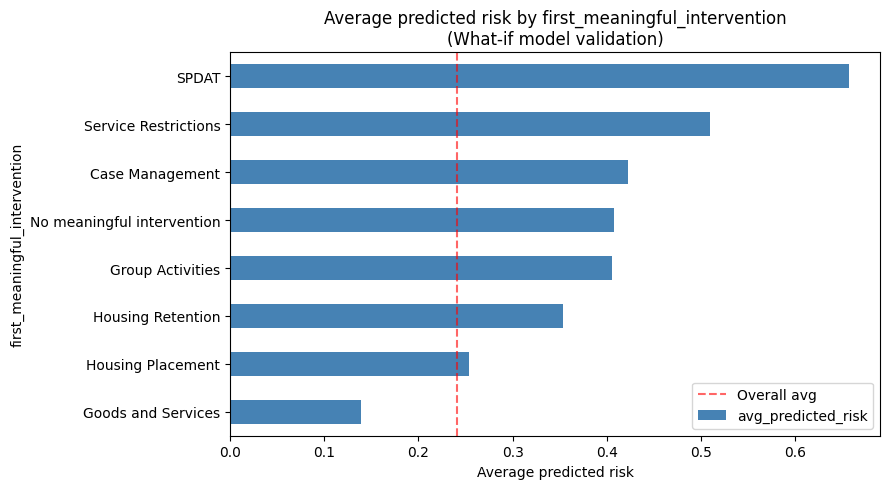


⚠️ These are ASSOCIATIONS, not causal effects. Caseworkers may assign different interventions to clients with different baseline risk.


In [16]:
# Show how predicted risk varies by first_meaningful_intervention
val_df = X_test.copy()
val_df['predicted_risk'] = y_pred_proba
val_df['actual_chronic'] = y_test.values

risk_by_intervention = (
    val_df.groupby('first_meaningful_intervention', observed=True)
          .agg(
              n_clients=('predicted_risk', 'count'),
              avg_predicted_risk=('predicted_risk', 'mean'),
              actual_chronic_rate=('actual_chronic', 'mean'),
          )
          .sort_values('avg_predicted_risk')
          .round(3)
)
print("Average predicted risk by first_meaningful_intervention (test set):")
print(risk_by_intervention.to_string())

risk_by_intervention['avg_predicted_risk'].sort_values().plot(
    kind='barh', color='steelblue', figsize=(9, 5)
)
plt.axvline(y_pred_proba.mean(), color='red', linestyle='--', alpha=0.6, label='Overall avg')
plt.title('Average predicted risk by first_meaningful_intervention\n(What-if model validation)')
plt.xlabel('Average predicted risk')
plt.legend()
plt.tight_layout()
plt.show()
print("\n⚠️ These are ASSOCIATIONS, not causal effects. Caseworkers may assign different interventions to clients with different baseline risk.")

## 7. SHAP — feature importance for what-if model

/Users/marieth/Documents/Marieth/DataForGood/waterloo_homelessness_ml/venv/lib/python3.11/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


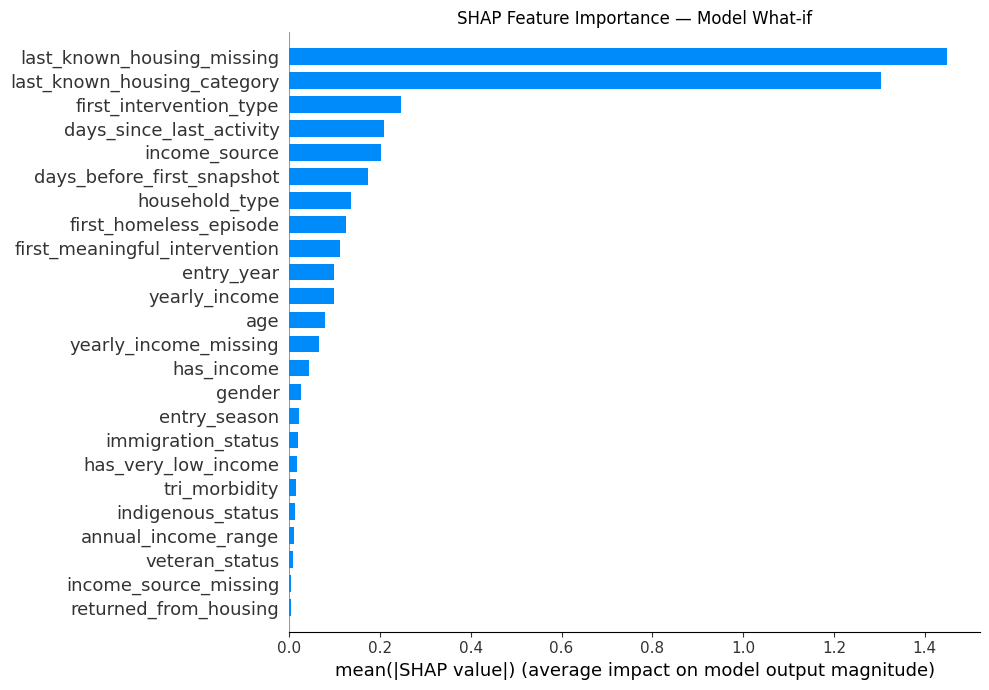

In [17]:
explainer = shap.TreeExplainer(model_wif)
shap_values = explainer.shap_values(X_test)
sv = shap_values[1] if isinstance(shap_values, list) else shap_values

shap.summary_plot(sv, X_test, plot_type='bar', max_display=24, show=False, plot_size=(10, 7))
plt.title('SHAP Feature Importance — Model What-if')
plt.tight_layout()
plt.show()

## 8. Save model artifact

In [18]:
today = date.today().strftime('%Y%m%d')
model_path = f'../models/phase_b_whatif_{today}.pkl'
joblib.dump({
    'model'        : model_wif,
    'feature_cols' : list(X_train.columns),
    'cat_features' : cat_cols_wif,
    'whatif_features': WHATIF_FEATURES,
}, model_path)
print(f"Model saved to: {model_path}")

Model saved to: ../models/phase_b_whatif_20260712.pkl
